In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [2]:
with open('Deterministic_results_with_initial_conditions.json') as json_file:
    F_results = json.load(json_file)


In [3]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [4]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)

# remove ongoing tenders
F_values_df = F_values_df[F_values_df.Start > 0]


In [7]:
F_values_df[F_values_df.Value == 1]

,Tender,Start,Finish,Value
85,Measles,1,5,1.0
178,Measles,6,10,1.0
55,Mumps,6,10,1.0
119,Mumps,1,5,1.0
309,Rubella,4,8,1.0
256,Rubella,6,10,1.0
147,Diphtheria,1,5,1.0
273,Diphtheria,6,10,1.0
6,Tetanus,6,10,1.0
79,Tetanus,1,5,1.0


In [5]:
#check to make sure all tenders are accounted for in model results
def lists_contain_same_strings(list1, list2):
    return set(list1) == set(list2)

# Example usage
list_a = list(F_values_df.Tender.unique())
list_b = ["Measles","Mumps","Rubella","Diphtheria","Tetanus","Pertussis",
          "Hepatitis_B","Hib","Polio","HPV","Rotavirus","PCV"]

lists_contain_same_strings(list_a, list_b)


True

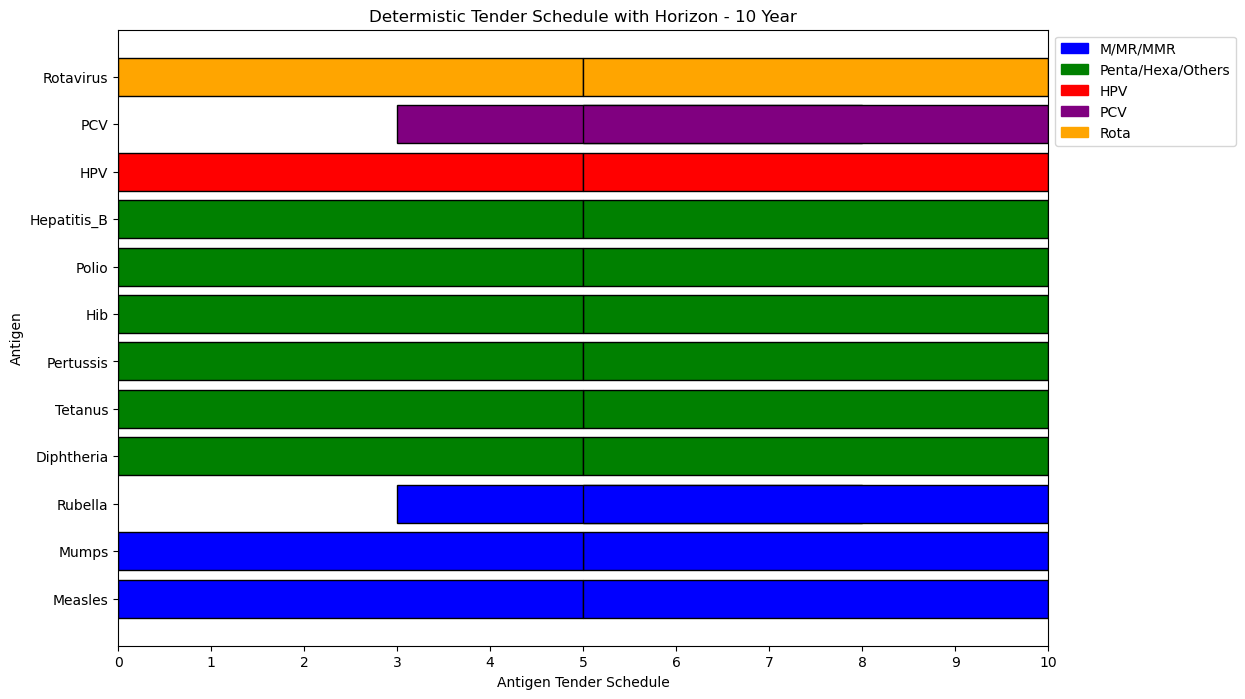

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming F_values_df is your DataFrame containing data

# Define the desired order
tender_order = ['Measles', 'Mumps', 'Rubella', 'Diphtheria', 'Tetanus', 'Pertussis', 'Hib', 'Polio', 'Hepatitis_B','HPV', 'PCV', 'Rotavirus']

# Define color groups
color_groups = {
    'M/MR/MMR': ['Measles', 'Mumps', 'Rubella'],
    'Penta/Hexa/Others': ['Diphtheria', 'Tetanus', 'Pertussis', 'Hib', 'Polio', 'Hepatitis_B'],
    'HPV': ['HPV'],
    'PCV': ['PCV'],
    'Rota': ['Rotavirus'],
}

# Convert the 'Tender' column to a categorical data type with the specified order
F_values_df['Tender'] = pd.Categorical(F_values_df['Tender'], categories=tender_order, ordered=True)

# Sort the DataFrame based on the categorical order
F_values_df = F_values_df.sort_values('Tender')

# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust figure size

# Define colors for each group
colors = {
    'M/MR/MMR': 'blue',
    'Penta/Hexa/Others': 'green',
    'HPV': 'red',
    'PCV': 'purple',
    'Rota': 'orange',
}

# Iterate through rows and plot bars based on conditions and color groups
for index, row in F_values_df.iterrows():
    if round(row['Value']) == 1:
        start = row['Start'] - 1
        end = row['Finish']
        
        # Choose color based on the group
        for group, tenders in color_groups.items():
            if row['Tender'] in tenders:
                color = colors[group]
                ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black', color=color)

# Set labels and show the plot
ax.set_xlim(0, 10)
ax.set_xticks(range(11))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule with Horizon - 10 Year')

# Create a legend with adjusted location
legend_labels = [plt.Rectangle((0,0),1,1, color=colors[group], label=group) for group in color_groups.keys()]
ax.legend(legend_labels, color_groups.keys(), loc='upper left', bbox_to_anchor=(1, 1))

# Add a dashed yellow line at the 10th tick on the x-axis
ax.axvline(x=10.04, color='yellow', linestyle='--', linewidth=2)

# Save and show the plot
# plt.savefig('Deterministic_Tenders_With_Start_Color_Groups_Same_Color.png')
plt.savefig('deterministic_horizon_tenders_only.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.show()
